# Forecasting one product with XGBoost

In the Prophet notebook, the model looked only at **dates** and learned the trend and seasonal patterns.
Here we try a different approach: **XGBoost**, a general-purpose machine-learning model.

XGBoost doesn't understand time on its own. Instead we give it a table where each row is one day,
with columns ("features") that describe that day, such as the weekday or what sales were a week ago.
It learns rules like *"if it's a Sunday in July and sales last week were high, expect about 30 units."*

We use the same product (**store 1, item 1**) and the same 8-week test period as the Prophet
notebook, so the results can be compared fairly.

In [1]:
# Install XGBoost and scikit-learn (XGBRegressor needs it) into this environment (only needed once)
%pip install xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Step 1: Load, filter and sort the data

Same as before: load the CSV, keep only store 1 / item 1, and sort by date.
Sorting matters even more here, because the next step looks "back in time" row by row,
which only works if the rows are in date order.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Load the full dataset; parse_dates turns the "date" column into real dates
sales_df = pd.read_csv("../data/train.csv", parse_dates=["date"])

# Keep only store 1, item 1, then sort by date.
# .copy() makes this an independent table, so adding columns later doesn't affect sales_df.
product_df = (
    sales_df[(sales_df["store"] == 1) & (sales_df["item"] == 1)]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

# The lag features below count ROWS, not calendar days. That's only correct if there's exactly
# one row per day with no gaps, so we check: the number of rows should equal the number of days.
expected_days = (product_df["date"].max() - product_df["date"].min()).days + 1
print("Rows:", len(product_df), "| Days in date range:", expected_days,
      "| No missing days:", len(product_df) == expected_days)
product_df.head()

Rows: 1826 | Days in date range: 1826 | No missing days: True


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Step 2: Create the features

A **feature** is a column the model uses as input to make a prediction. We create two kinds:

**Calendar features**, taken from the date:
- `day_of_week`: 0 = Monday ... 6 = Sunday (captures the weekly pattern)
- `month`: 1 = January ... 12 = December (captures the yearly pattern)
- `year`: captures the long-term growth from year to year

**Past-sales features**, which tell the model how the product has been selling recently:
- `lag_7`: sales exactly 7 days earlier (the same weekday last week)
- `lag_14`: sales exactly 14 days earlier (the same weekday two weeks ago)
- `lag_365`: sales exactly 365 days earlier (roughly the same day last year)
- `rolling_mean_7`: average sales over the previous 7 days, **not** including today

We never let a feature include the day's own sales. That would give the model the answer.

In [3]:
# --- Calendar features ---
# The .dt accessor gives date parts for every row at once
product_df["day_of_week"] = product_df["date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
product_df["month"] = product_df["date"].dt.month            # 1-12
product_df["year"] = product_df["date"].dt.year              # e.g. 2016

# --- Lag features ---
# .shift(n) moves a column DOWN by n rows. After shifting by 7, each row holds the value
# from 7 rows (= 7 days) earlier. The first 7 rows have nothing above them, so they get NaN
# (pandas' marker for "missing").
#
#   date        sales   sales.shift(7)
#   2013-01-01  13      NaN
#   ...
#   2013-01-08  9       13    <- the value from 2013-01-01
product_df["lag_7"] = product_df["sales"].shift(7)
product_df["lag_14"] = product_df["sales"].shift(14)
product_df["lag_365"] = product_df["sales"].shift(365)

# --- Rolling average ---
# .rolling(7) looks at a moving "window" of 7 rows at a time; .mean() averages each window.
# On its own, the window for a row covers that row and the 6 before it, which includes today.
# So we .shift(1) first: the window then covers the 7 days BEFORE today, and excludes today.
product_df["rolling_mean_7"] = product_df["sales"].shift(1).rolling(7).mean()

feature_columns = ["day_of_week", "month", "year", "lag_7", "lag_14", "lag_365", "rolling_mean_7"]
product_df[["date", "sales"] + feature_columns].tail()

,date,sales,day_of_week,month,year,lag_7,lag_14,lag_365,rolling_mean_7
1821,2017-12-27,14,2,12,2017,16.0,17.0,10.0,14.285714
1822,2017-12-28,19,3,12,2017,12.0,14.0,16.0,14.000000
1823,2017-12-29,15,4,12,2017,6.0,16.0,21.0,15.000000
1824,2017-12-30,27,5,12,2017,18.0,15.0,24.0,16.285714
1825,2017-12-31,23,6,12,2017,19.0,22.0,14.0,17.571429


## Step 3: Remove rows with missing features

The first 365 rows have no `lag_365` value, because there is no "last year" in the data yet.
The model can't learn from incomplete rows, so we drop them. This removes roughly the first year.

In [4]:
rows_before = len(product_df)

# .dropna(subset=[...]) removes any row with a missing value (NaN) in those columns
model_df = product_df.dropna(subset=feature_columns).reset_index(drop=True)

print("Rows before:", rows_before)
print("Rows after: ", len(model_df), f"({rows_before - len(model_df)} dropped)")
print("Data now starts on:", model_df["date"].min().date())

Rows before: 1826
Rows after:  1461 (365 dropped)
Data now starts on: 2014-01-01


## Step 4: Split into training and test sets by date

Same rule as the Prophet notebook: the **last 8 weeks** are the test set and everything
before that is training. We split by date, never randomly, so the model can't learn from the future.

**One important difference from Prophet.** Prophet forecast all 8 weeks using only the
training data. Here, the lag and rolling-average features for test days are calculated from
**real** sales. For example, `lag_7` on the last test day is the real sales from a week before it,
which is itself inside the test period. So XGBoost gets fresh real data throughout the 8 weeks,
which Prophet didn't. This is like forecasting **a few days ahead** rather than
**8 weeks ahead**, and gives XGBoost an advantage. Keep this in mind when comparing the results below.

In [5]:
# Same test period as the Prophet notebook: the last 56 days (8 weeks)
last_date = model_df["date"].max()
test_start_date = last_date - pd.Timedelta(weeks=8) + pd.Timedelta(days=1)

train_df = model_df[model_df["date"] < test_start_date]
test_df = model_df[model_df["date"] >= test_start_date]

# ML convention: X = the inputs (features), y = what we want to predict (sales)
X_train, y_train = train_df[feature_columns], train_df["sales"]
X_test, y_test = test_df[feature_columns], test_df["sales"]

print(f"Training set: {len(train_df)} days ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test set:     {len(test_df)} days ({test_df['date'].min().date()} to {test_df['date'].max().date()})")

Training set: 1405 days (2014-01-01 to 2017-11-05)
Test set:     56 days (2017-11-06 to 2017-12-31)


## Step 5: Train the XGBoost model

XGBoost builds hundreds of small **decision trees** (flowcharts of yes/no questions such as
"is lag_7 above 20?"). Each new tree focuses on correcting the mistakes of the trees before it,
and the final prediction adds up all their answers.

In [6]:
model = XGBRegressor(
    n_estimators=500,    # how many trees to build
    learning_rate=0.05,  # how much each new tree is allowed to correct; small = slower but steadier learning
    max_depth=4,         # how many questions deep each tree can go; small = simpler trees, less overfitting
    random_state=42,     # fixes the randomness so you get the same result every time you run it
)

# .fit(X, y) trains the model: it learns how the features (X) relate to sales (y)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Step 6: Predict the test period and measure accuracy

We use the same two metrics as in the Prophet notebook:
- **MAPE**: the average error as a percentage of real sales ("off by X% on average"). Lower is better.
- **RMSE**: the typical size of a daily error in units sold, with big misses counting extra. Lower is better.

In [7]:
# .predict(X) gives one predicted sales number for each row of features
predicted_sales = model.predict(X_test)
actual_sales = y_test.to_numpy()

# Exactly the same formulas as the Prophet notebook
errors = predicted_sales - actual_sales
nonzero_days = actual_sales != 0  # leave out days with 0 sales to avoid dividing by zero
xgb_mape = (abs(errors[nonzero_days]) / actual_sales[nonzero_days]).mean() * 100
xgb_rmse = ((errors ** 2).mean()) ** 0.5

print(f"MAPE: {xgb_mape:.2f}%")
print(f"RMSE: {xgb_rmse:.2f} units")

MAPE: 25.20%
RMSE: 4.92 units


## Step 7: Compare with the best Prophet model

The best Prophet model was **Tuned (cps=0.5)**. Its numbers are typed in below from the Prophet
notebook's results. Remember the caveat from Step 4: XGBoost had the advantage of seeing recent
real sales during the test period.

In [8]:
comparison_df = pd.DataFrame([
    {"model": "Prophet - Tuned (cps=0.5)", "MAPE (%)": 23.19, "RMSE": 4.55},
    {"model": "XGBoost", "MAPE (%)": xgb_mape, "RMSE": xgb_rmse},
])

print("Comparison on the same 8-week test set (lower is better):\n")
print(comparison_df.round(2).to_string(index=False))

# .idxmin() finds the row with the lowest MAPE; .loc[] fetches that row
best_row = comparison_df.loc[comparison_df["MAPE (%)"].idxmin()]
print(f"\nBest by MAPE: {best_row['model']} ({best_row['MAPE (%)']:.2f}%).")

Comparison on the same 8-week test set (lower is better):

                    model  MAPE (%)  RMSE
Prophet - Tuned (cps=0.5)     23.19  4.55
                  XGBoost     25.20  4.92

Best by MAPE: Prophet - Tuned (cps=0.5) (23.19%).


## Step 8: Which features mattered most?

**Feature importance** is a score for how much each feature helped the model's predictions.
A feature gets credit every time a tree uses it to split the data and the split makes the predictions
more accurate. A high score means the model relied on it heavily. A score near zero means it barely
used it.

This tells you what drives the forecast. It doesn't tell you whether a feature pushes sales up or down.

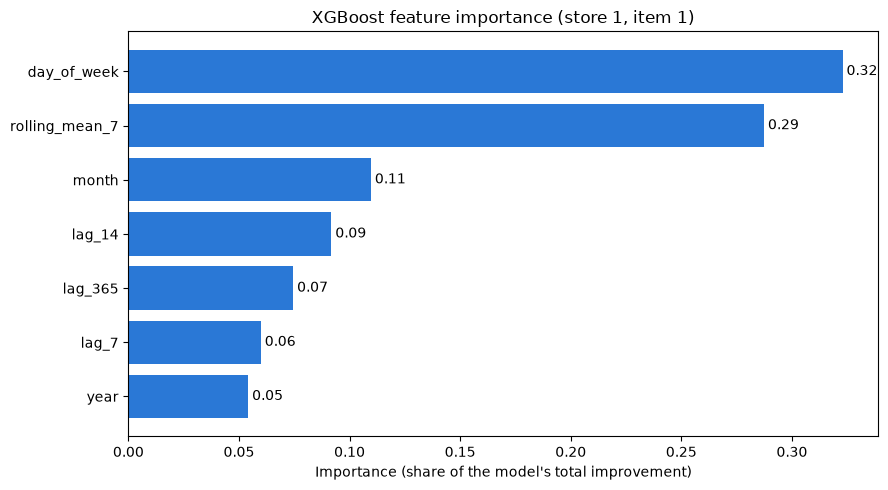

In [9]:
# model.feature_importances_ holds one score per feature, in the same order as feature_columns.
# We put them in a pandas Series (a single labelled column) and sort from smallest to largest,
# so the most important feature ends up at the top of a horizontal bar chart.
feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_importance.index, feature_importance.values, color="#2a78d6")  # barh = horizontal bars
ax.set_title("XGBoost feature importance (store 1, item 1)")
ax.set_xlabel("Importance (share of the model's total improvement)")

# Write each score at the end of its bar
for position, value in enumerate(feature_importance.values):
    ax.text(value, position, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

## Step 9: Compare the forecast to reality on a chart

Same layout as the Prophet notebook: the full history on top, and a zoomed-in view of the last
few months below it for a day-by-day comparison. The training line starts in 2014, because
the first year was dropped in Step 3.

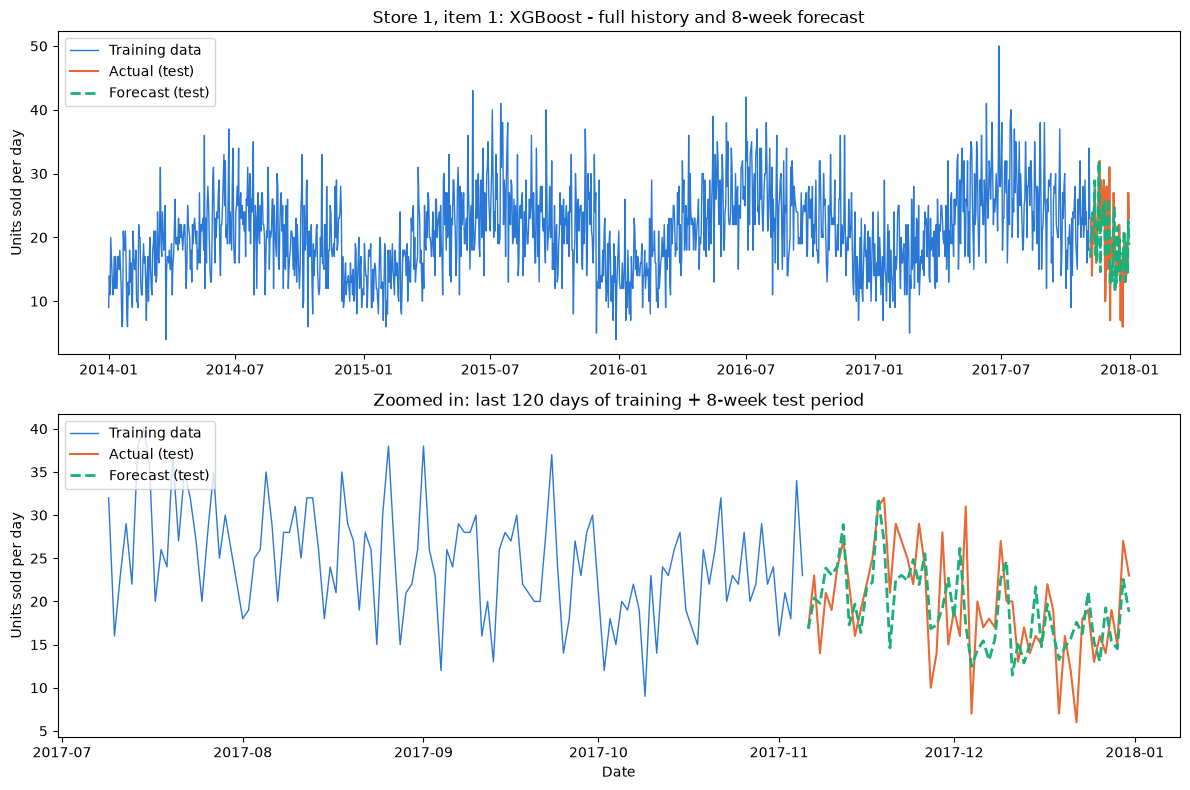

In [10]:
# plt.subplots(2, 1) creates two charts stacked on top of each other
fig, (full_ax, zoom_ax) = plt.subplots(2, 1, figsize=(12, 8))

# Same colours as the Prophet notebook: training blue, actual orange, forecast green (dashed)
TRAIN_COLOR, ACTUAL_COLOR, FORECAST_COLOR = "#2a78d6", "#eb6834", "#1baf7a"

# Only show the last 120 days of training data in the zoomed chart
zoom_train_df = train_df[train_df["date"] >= test_start_date - pd.Timedelta(days=120)]

for ax, train_part in [(full_ax, train_df), (zoom_ax, zoom_train_df)]:
    ax.plot(train_part["date"], train_part["sales"], color=TRAIN_COLOR, linewidth=1, label="Training data")
    ax.plot(test_df["date"], actual_sales, color=ACTUAL_COLOR, linewidth=1.5, label="Actual (test)")
    ax.plot(test_df["date"], predicted_sales, color=FORECAST_COLOR, linewidth=2,
            linestyle="--", label="Forecast (test)")
    ax.set_ylabel("Units sold per day")
    ax.legend(loc="upper left")

full_ax.set_title("Store 1, item 1: XGBoost - full history and 8-week forecast")
zoom_ax.set_title("Zoomed in: last 120 days of training + 8-week test period")
zoom_ax.set_xlabel("Date")

plt.tight_layout()
plt.show()